# Pipeline di Classificazione Curriculum Vitae (Resume)

Questo notebook implementa una pipeline di Machine Learning per classificare i CV in categorie.

**Step:**
1. Caricamento e Pulizia Dati
2. Split del Dataset (Train / Validation / Test)
3. Feature Extraction (TF-IDF)
4. Addestramento Modello (Linear SVM)
5. Valutazione
6. Inferenza

In [2]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import re
import seaborn as sns
import string
%load_ext autoreload
%autoreload 2
from tools import utils as u, plotting as up

RANDOM_STATE = 42

# 1. Caricamento e Preprocessing dei Dati

In [ ]:
# preprocessamento -> basta eseguirlo una volta nella vita e poi lo salviamo (tempo di esecuzione ~1m 16s)
df = pd.read_csv('data/Resume.csv')
df['text'] = df['Resume_str'].apply(u.preprocess_text)
df.to_csv('data/ppresume.csv')

Dataset caricato con successo: 2484 righe, 6 colonne

Distribuzione delle Categorie:
Media: 103.5
Valori sotto la media: ['ARTS', 'TEACHER', 'APPAREL', 'DIGITAL-MEDIA', 'AGRICULTURE', 'AUTOMOBILE', 'BPO']
Valori nulli: 2484
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


/tmp/ipykernel_18967/3912579877.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories.index, rotation=45, ha="right")


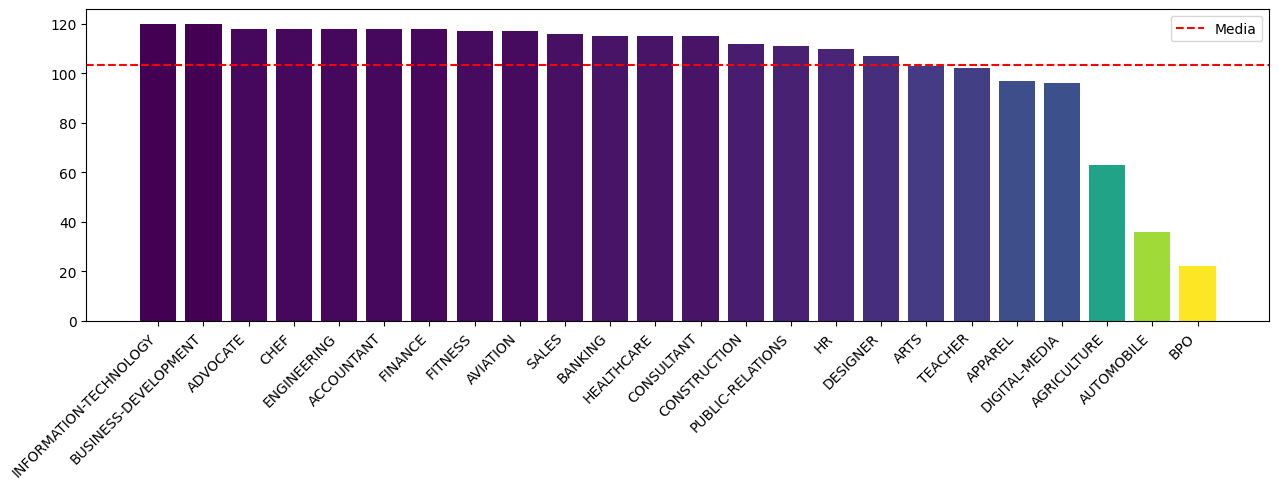

In [4]:
df = pd.read_csv('data/ppresume.csv')

## ------- Visualizzazione delle classi e altri dati
print(f"Dataset caricato con successo: {df.shape[0]} righe, {df.shape[1]} colonne")
print("\nDistribuzione delle Categorie:")

categories = df['Category'].value_counts()
meanv = categories.values.mean()

print(f"Media: {meanv}")
print(f"Valori sotto la media: {list(categories[categories < meanv].index)}")
print(f"Valori nulli: {df['text'].isna().count()}")
print(categories)
df = df.dropna()


## ------ PLOT
fig, ax = plt.subplots(figsize=(13, 5))
norm = plt.Normalize(categories.min(), categories.max())
colors = plt.cm.viridis_r(norm(categories.values))
ax.bar(categories.index, categories.values, color=colors)
ax.axhline(y=meanv, color='r', linestyle='--', label='Media')
ax.set_xticklabels(categories.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## 1.1 Wordcloud

In [ ]:
MAX_WORDS = 500

wc = WordCloud(
    width=800, 
    height=700, 
    background_color='white',
    max_words=MAX_WORDS,
    contour_width=0,
    colormap='viridis'  # 'viridis', 'plasma', or 'inferno' work well for data
)

fig = up.wordcloud(wc, df["text"], MAX_WORDS, ENGLISH_STOP_WORDS)
fig.savefig("data/wordcloud/wordcloud_overall.png", dpi=300)

for category in df['Category'].unique():
    category_df = df[df['Category'] == category]
    fig = up.wordcloud(wc, category_df["text"], MAX_WORDS, ENGLISH_STOP_WORDS)
    fig.savefig(f"data/wordcloud/wordcloud_{category}.png", dpi=300)


# 2 Feature Extraction
Esistono due principali metodologie di Feature Extraction:
- Bag of words
- TF-IDF

In [ ]:
# Step 1: preprocessing (è già stato fatto nella wordcloud)
# df["text"] = df["Resume_str"].apply(u.preprocess_text)
# df["text"].sample(10)

# Step 2: parole univoche (solo per dimostrazione)
unique_words = u.unique_text(df["text"])
print(len(unique_words))
wordsdf = pd.DataFrame(unique_words)

word2count = {} 
for data in df["text"]: 
    words = nltk.word_tokenize(data) 
    for word in words: 
        if word not in word2count.keys(): 
            word2count[word] = 1
        else: 
            word2count[word] += 1


## TF-IDF
Utilizziamo **TF-IDF (Term Frequency - Inverse Document Frequency)**. 
È molto efficace per il testo perché penalizza le parole troppo comuni (stop words) e valorizza quelle distintive per ogni categoria.
TF-IDF è il prodotto di TF e IDF, dove la prima è alta per un termine che si ripete tante volte all'interno di un documento e la seconda, invece, è alta se lo stesso termine si ripete raramente tra tutti i documenti. In questo caso signfica che il termine ha molta rilevanza per categorizzare un documento e distinguerlo da altri.

In [5]:
# Inizializzazione del vettorizzatore
# max_features=5000 limita il vocabolario alle 5000 parole più importanti per ridurre la dimensionalità
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 3))
X = vectorizer.fit_transform(df["text"])
y = df["Category"]

print(f"Shape della matrice di feature (Train): {X.shape}")

Shape della matrice di feature (Train): (2483, 3000)


# 3. Suddivisione del Dataset (Train + Validation + Test)

Suddividiamo i dati in:
- **Train Set (70%)**: Per addestrare il modello.
- **Validation Set (15%)**: Per il tuning degli iperparametri (implicito in questa pipeline semplificata).
- **Test Set (15%)**: Per la valutazione finale imparziale.

In [ ]:
# con stratify per impedire assenza di rappresentatività
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

print(f"Dimensioni Train: {X_train.shape[0]}")
print(f"Dimensioni Validation: {X_val.shape[0]}")
print(f"Dimensioni Test: {X_test.shape[0]}")

## 2.1 K-Fold

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier


def fold_generator(skf, X, y):
    for train_index, val_index in skf.split(X, y):
        # Check if X has the .iloc attribute (Pandas)
        if hasattr(X, 'iloc'):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        else:
            # For sparse matrices (csr_matrix) and NumPy arrays
            X_train, X_val = X[train_index], X[val_index]
            
        # y is usually still a Pandas Series or NumPy array
        if hasattr(y, 'iloc'):
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        else:
            y_train, y_val = y[train_index], y[val_index]
            
        yield X_train, X_val, y_train, y_val
# scores = cross_val_score(model, X_develop, y_develop, cv=skf, scoring='accuracy')

# 4. Addestramento del Classificatore

## Confronto Modelli
Implementiamo un confronto tra diversi modelli:
- **Naive Bayes**: sebbene più veloce, tende a essere superato dalle SVM nella gestione delle dipendenze tra termini.
- **Random Forest**: risulta spesso inefficiente su vettori sparsi di grandi dimensioni senza una preventiva riduzione della dimensionalità.
- **Deep Learning**: una rete neurale feed-forward su dati TF-IDF raramente offre vantaggi significativi rispetto a una SVM lineare, a fronte di una maggiore complessità gestionale.

In [ ]:
# Dizionario per salvare i risultati
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit


models = {}

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, stratify=y)

# skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
skf = StratifiedShuffleSplit(n_splits=15, random_state=RANDOM_STATE)

best_acc = 0.0
model = None
best_model_details = {}

def gen_classifier(classifier):
    return Pipeline([
        ('tfidf', TfidfVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 3))),
        ('classifier', classifier)
    ])

print("--- Confronto Performance (Accuracy su Test Set) ---")
j = 0
for i, (X_train, X_val, y_train, y_val) in enumerate(fold_generator(skf, X, y)):
    models[i] = {}
    # 1. Linear SVC
    model = LinearSVC(random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    models[i]['Linear SVC'] = {}
    models[i]['Linear SVC']["model"] = model

    # 2. Naive Bayes
    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)
    models[i]['Naive Bayes'] = {}
    models[i]['Naive Bayes']["model"] = nb_model

    # 3. Random Forest
    rf_model = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE)
    rf_model.fit(X_train, y_train)
    models[i]['Random Forest'] = {}
    models[i]['Random Forest']["model"] = rf_model

    # 4. Deep Learning (MLP)
    dl_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, verbose=False, random_state=RANDOM_STATE)
    dl_model.fit(X_train, y_train)
    models[i]['Deep Learning (MLP)'] = {}
    models[i]['Deep Learning (MLP)']["model"] = dl_model


    print(f"RUN {i}--------")
    for name, mod_info in models[i].items():
        trained_model = mod_info['model'] 
        
        # Calculate performance
        preds = trained_model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        
        # Store result in the dictionary
        mod_info['result'] = acc
        j += 1
        print(f"{j}--{name}: {acc:.4f}")

        # --- LOGIC TO TRACK THE BEST MODEL ---
        if acc > best_acc:
            best_acc = acc
            model = trained_model
            best_model_details = {
                'name': name,
                'run': i,
                'accuracy': acc
            }

print("-" * 30)
print(f"Migliore Risultato: {best_acc:.4f}")
print(f"Modello Vincitore: {best_model_details['name']} (Run: {best_model_details['run']})")

# Now 'best_model_obj' is your ready-to-use production model

--- Confronto Performance (Accuracy su Test Set) ---
RUN 0--------
1--Linear SVC: 0.6867
2--Naive Bayes: 0.5462
3--Random Forest: 0.6627
4--Deep Learning (MLP): 0.6345
RUN 1--------
5--Linear SVC: 0.6586
6--Naive Bayes: 0.5422
7--Random Forest: 0.6747
8--Deep Learning (MLP): 0.6104
RUN 2--------
9--Linear SVC: 0.6586
10--Naive Bayes: 0.5341
11--Random Forest: 0.6667
12--Deep Learning (MLP): 0.6265
RUN 3--------
13--Linear SVC: 0.6386
14--Naive Bayes: 0.5863
15--Random Forest: 0.6386
16--Deep Learning (MLP): 0.5984
RUN 4--------
17--Linear SVC: 0.6386
18--Naive Bayes: 0.4980
19--Random Forest: 0.6265
20--Deep Learning (MLP): 0.5823
RUN 5--------
21--Linear SVC: 0.6466
22--Naive Bayes: 0.5462
23--Random Forest: 0.6627
24--Deep Learning (MLP): 0.5863
RUN 6--------
25--Linear SVC: 0.6466
26--Naive Bayes: 0.5341
27--Random Forest: 0.6104
28--Deep Learning (MLP): 0.5944
RUN 7--------
29--Linear SVC: 0.6586
30--Naive Bayes: 0.5422
31--Random Forest: 0.6586
32--Deep Learning (MLP): 0.6104
RUN 

# 5. Valutazione del Modello
Valutiamo le performance sul **Test Set**.

In [9]:
X_val = X
y_val = y

y_pred = model.predict(X_val)

print("--- Classification Report (Test Set) ---")
print(classification_report(y_val, y_pred))

print(f"Accuracy finale: {accuracy_score(y_val, y_pred):.4f}")

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

            ACCOUNTANT       0.95      0.97      0.96       118
              ADVOCATE       0.94      0.92      0.93       118
           AGRICULTURE       0.97      0.94      0.95        63
               APPAREL       0.95      0.92      0.93        97
                  ARTS       0.98      0.91      0.94       103
            AUTOMOBILE       1.00      0.86      0.93        36
              AVIATION       0.94      0.97      0.95       117
               BANKING       0.94      0.98      0.96       115
                   BPO       1.00      0.86      0.93        22
  BUSINESS-DEVELOPMENT       0.97      0.97      0.97       119
                  CHEF       0.97      0.96      0.96       118
          CONSTRUCTION       0.97      0.99      0.98       112
            CONSULTANT       0.95      0.90      0.93       115
              DESIGNER       0.97      0.98      0.98       10

In [ ]:
labels = sorted(y_val.unique())
cm = confusion_matrix(y_val, y_pred, labels=labels)
fig = px.imshow(cm, x=labels, y=labels, color_continuous_scale='Blues',
                labels=dict(x='Predetto', y='Reale', color='Count'),
                text_auto=True, title='Matrice di Confusione', height=800, width=800)
fig.update_layout(xaxis_title='Predetto', yaxis_title='Reale')
fig.show()

# 6. Inferenza
Utilizziamo il modello addestrato su un nuovo testo mai visto.

In [10]:
counter = 0
errori = []
stack = df.copy()
while True:
    # 1. Prendi un indice casuale
    idx = None
    try:
        idx = stack.sample(1).index[0]
    except:
        break
    # 2. Estrai i dati (il "pop" vero e proprio)
    sr = stack.loc[idx]
    
    # 3. Rimuovi la riga dallo stack usando l'indice e inplace=True
    stack.drop(idx, inplace=True)

    text = sr['text']
    truth_label = sr['Category']

    # Il resto del tuo codice rimane uguale
    svec = vectorizer.transform([text])
    prediction = model.predict(svec)[0]
    counter += 1
    
    if prediction != truth_label:
        #print(f"Dopo {counter} tentativi")
        # print(f"Testo Input:\n{text.strip()}")
        # print(f"\nCategoria Predetta: {prediction}")
        # print(f"Categoria Reale: {truth_label}")
        errori.append(counter)
        counter = 0

print(f"Errori {len(errori)}")
print(f"In media uno ogni {np.mean(errori)}")

Errori 105
In media uno ogni 23.295238095238094
